# Y Combinator Company Growth Rate Analysis

This notebook explores the change in growth rates amongst Y Combinator companies started in different years.

## Objectives:
- Analyze valuation growth patterns across different YC batch years
- Compare growth trajectories of companies from different eras
- Identify trends in startup valuations over time
- Examine the impact of market conditions on YC company growth

In [3]:
!pip install pandas numpy matplotlib seaborn jupyter


[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("📊 Libraries loaded successfully")

📊 Libraries loaded successfully


## 1. Data Loading and Exploration

In [5]:
# Connect to the SQLite database and load data
conn = sqlite3.connect('yc_valuations.db')

# Load companies data
companies_df = pd.read_sql_query("""
    SELECT company, batch, yc_year, status, final_year, end_reason
    FROM companies
    WHERE status = 'completed'
""", conn)

# Load valuations data with company info
valuations_df = pd.read_sql_query("""
    SELECT v.company, v.year, v.valuation, v.source, v.notes,
           c.yc_year, c.batch, c.final_year, c.end_reason
    FROM valuations v
    JOIN companies c ON v.company = c.company
    WHERE c.status = 'completed'
    ORDER BY c.yc_year, v.company, v.year
""", conn)

conn.close()

print(f"📈 Loaded data for {len(companies_df)} companies")
print(f"📊 Total valuations: {len(valuations_df)}")
print(f"🗓️  YC years range: {companies_df['yc_year'].min()} - {companies_df['yc_year'].max()}")

📈 Loaded data for 191 companies
📊 Total valuations: 1918
🗓️  YC years range: 2005 - 2013


In [6]:
# Display basic info about the dataset
print("Companies by YC Year:")
print(companies_df['yc_year'].value_counts().sort_index().head(10))

print("\nEnd Reasons:")
print(companies_df['end_reason'].value_counts())

print("\nSample of valuations data:")
display(valuations_df.head())

Companies by YC Year:
yc_year
2005     8
2006    18
2007    30
2008    31
2009    31
2010    50
2011    22
2013     1
Name: count, dtype: int64

End Reasons:
end_reason
acquired                            58
still_operating                     43
shutdown                            36
transformed into another company     1
insufficient_information             1
insufficient_data                    1
unable_to_verify                     1
pivoted                              1
Name: count, dtype: int64

Sample of valuations data:


,company,year,valuation,source,notes,yc_year,batch,final_year,end_reason
0,Clickfacts,2005,YC investment (estimated $6-25K for 6-7% equity),https://www.ycombinator.com/companies/clickfacts,"Founded 2005, Y Combinator Summer 2005 batch i...",2005,Summer 2005,NaN,None
1,Clickfacts,2006,Not found,Various searches conducted,No specific valuation data found for 2006,2005,Summer 2005,NaN,None
2,Clickfacts,2007,Company ceased operations (July 2007),https://www.boringbusinessnerd.com/post/y-comb...,Company stopped operating in July 2007 when co...,2005,Summer 2005,NaN,None
3,Clickfacts,2008,Not operating,https://www.boringbusinessnerd.com/post/y-comb...,Company had already ceased operations in 2007,2005,Summer 2005,NaN,None
4,Clickfacts,2009,Not operating,https://www.boringbusinessnerd.com/post/y-comb...,Company had already ceased operations in 2007,2005,Summer 2005,NaN,None


## 2. Data Cleaning and Valuation Parsing

In [7]:
def parse_valuation(valuation_str):
    """
    Parse valuation string to numeric value in USD.
    Returns None for non-numeric valuations.
    """
    if pd.isna(valuation_str) or not isinstance(valuation_str, str):
        return None
    
    val_str = valuation_str.lower().strip()
    
    # Skip non-numeric valuations
    skip_phrases = ['not found', 'not disclosed', 'no public', 'undisclosed', 'acquired', 'public company']
    if any(phrase in val_str for phrase in skip_phrases):
        return None
    
    # Extract numeric value and multiplier
    # Look for patterns like $1.2B, $50M, $120K, etc.
    match = re.search(r'\$?([0-9.,]+)\s*([kmb])?', val_str)
    if not match:
        return None
    
    try:
        number = float(match.group(1).replace(',', ''))
        multiplier = match.group(2)
        
        if multiplier == 'k':
            return number * 1_000
        elif multiplier == 'm':
            return number * 1_000_000
        elif multiplier == 'b':
            return number * 1_000_000_000
        else:
            return number
    except:
        return None

# Test the parsing function
test_values = ['$1.2B', '$50M', '$120K', 'Not found', 'Acquired for $2B', '$95,000']
for val in test_values:
    print(f"{val} -> {parse_valuation(val)}")

$1.2B -> 1200000000.0
$50M -> 50000000.0
$120K -> 120000.0
Not found -> None
Acquired for $2B -> None
$95,000 -> 95000.0


In [8]:
# Apply valuation parsing
valuations_df['valuation_numeric'] = valuations_df['valuation'].apply(parse_valuation)

# Filter to only numeric valuations
numeric_valuations = valuations_df[valuations_df['valuation_numeric'].notna()].copy()

print(f"📊 Numeric valuations: {len(numeric_valuations)} out of {len(valuations_df)} total")
print(f"📈 Coverage: {len(numeric_valuations)/len(valuations_df)*100:.1f}%")

# Show distribution of valuation ranges
print("\nValuation Distribution:")
bins = [0, 1e6, 10e6, 100e6, 1e9, 10e9, float('inf')]
labels = ['<$1M', '$1M-$10M', '$10M-$100M', '$100M-$1B', '$1B-$10B', '>$10B']
numeric_valuations['valuation_bucket'] = pd.cut(numeric_valuations['valuation_numeric'], bins=bins, labels=labels)
print(numeric_valuations['valuation_bucket'].value_counts())

📊 Numeric valuations: 371 out of 1918 total
📈 Coverage: 19.3%

Valuation Distribution:
valuation_bucket
<$1M          131
$1M-$10M       67
$10M-$100M     63
$1B-$10B       42
$100M-$1B      24
>$10B          20
Name: count, dtype: int64


## 3. Growth Rate Calculations

In [9]:
def calculate_growth_metrics(company_data):
    """
    Calculate growth metrics for a single company.
    """
    # Sort by year
    company_data = company_data.sort_values('year')
    
    if len(company_data) < 2:
        return None
    
    first_val = company_data.iloc[0]
    last_val = company_data.iloc[-1]
    
    years_elapsed = last_val['year'] - first_val['year']
    if years_elapsed <= 0:
        return None
    
    # Calculate CAGR (Compound Annual Growth Rate)
    if first_val['valuation_numeric'] > 0:
        cagr = (last_val['valuation_numeric'] / first_val['valuation_numeric']) ** (1/years_elapsed) - 1
    else:
        cagr = None
    
    return {
        'company': first_val['company'],
        'yc_year': first_val['yc_year'],
        'first_year': first_val['year'],
        'last_year': last_val['year'],
        'years_tracked': years_elapsed,
        'first_valuation': first_val['valuation_numeric'],
        'last_valuation': last_val['valuation_numeric'],
        'total_growth': last_val['valuation_numeric'] / first_val['valuation_numeric'] if first_val['valuation_numeric'] > 0 else None,
        'cagr': cagr,
        'end_reason': first_val['end_reason']
    }

# Calculate growth metrics for each company
growth_metrics = []
for company in numeric_valuations['company'].unique():
    company_data = numeric_valuations[numeric_valuations['company'] == company]
    metrics = calculate_growth_metrics(company_data)
    if metrics:
        growth_metrics.append(metrics)

growth_df = pd.DataFrame(growth_metrics)

print(f"📈 Calculated growth metrics for {len(growth_df)} companies")
print(f"📊 Average CAGR: {growth_df['cagr'].mean():.1%}")
print(f"📊 Median CAGR: {growth_df['cagr'].median():.1%}")

display(growth_df.head())

📈 Calculated growth metrics for 63 companies
📊 Average CAGR: 178.6%
📊 Median CAGR: 53.7%


,company,yc_year,first_year,last_year,years_tracked,first_valuation,last_valuation,total_growth,cagr,end_reason
0,Clickfacts,2005,2005,2012,7,6.0,2.012000e+03,335.333333,1.294998,None
1,Loopt,2005,2005,2010,5,6000.0,1.500000e+07,2500.000000,3.781762,None
2,Memamp,2005,2005,2009,4,6000.0,1.000000e+00,0.000167,-0.886378,None
3,Reddit,2005,2014,2025,11,500000000.0,4.500000e+10,90.000000,0.505423,None
4,Clustrix,2006,2010,2017,7,100000000.0,3.000000e+07,0.300000,-0.158018,None


## 4. Growth Analysis by YC Batch Year

In [10]:
# Filter out extreme outliers for better visualization
# Remove companies with CAGR > 1000% or < -50% (likely data errors)
filtered_growth = growth_df[
    (growth_df['cagr'] > -0.5) & 
    (growth_df['cagr'] < 10) &
    (growth_df['years_tracked'] >= 2)
].copy()

print(f"📊 After filtering: {len(filtered_growth)} companies (removed {len(growth_df) - len(filtered_growth)} outliers)")

# Group by YC year and calculate statistics
yearly_stats = filtered_growth.groupby('yc_year').agg({
    'cagr': ['count', 'mean', 'median', 'std'],
    'total_growth': ['mean', 'median'],
    'first_valuation': 'median',
    'last_valuation': 'median'
}).round(3)

yearly_stats.columns = ['_'.join(col).strip() for col in yearly_stats.columns.values]
yearly_stats = yearly_stats.reset_index()

print("\nGrowth Statistics by YC Year:")
display(yearly_stats.head(10))

📊 After filtering: 49 companies (removed 14 outliers)

Growth Statistics by YC Year:


,yc_year,cagr_count,cagr_mean,cagr_median,cagr_std,total_growth_mean,total_growth_median,first_valuation_median,last_valuation_median
0,2005,3,1.861,1.295,1.710,975.111,335.333,6000.0,1.500000e+07
1,2006,6,0.922,0.782,0.729,3437.304,140.753,2562500.0,4.882100e+08
2,2007,9,0.703,0.702,0.514,2719.214,753.846,500000.0,1.250000e+08
3,2008,6,0.264,0.224,0.295,113.692,3.971,2825000.0,1.810000e+07
4,2009,11,0.781,0.723,0.697,350502.356,21.687,1650000.0,4.320000e+07
5,2010,7,0.573,0.414,0.725,512.395,30.000,800000.0,1.500000e+08
6,2011,6,0.596,0.448,0.537,429.897,41.585,1125000.0,1.655000e+07
7,2013,1,2.136,2.136,NaN,906000.000,906000.000,120000.0,1.087200e+11


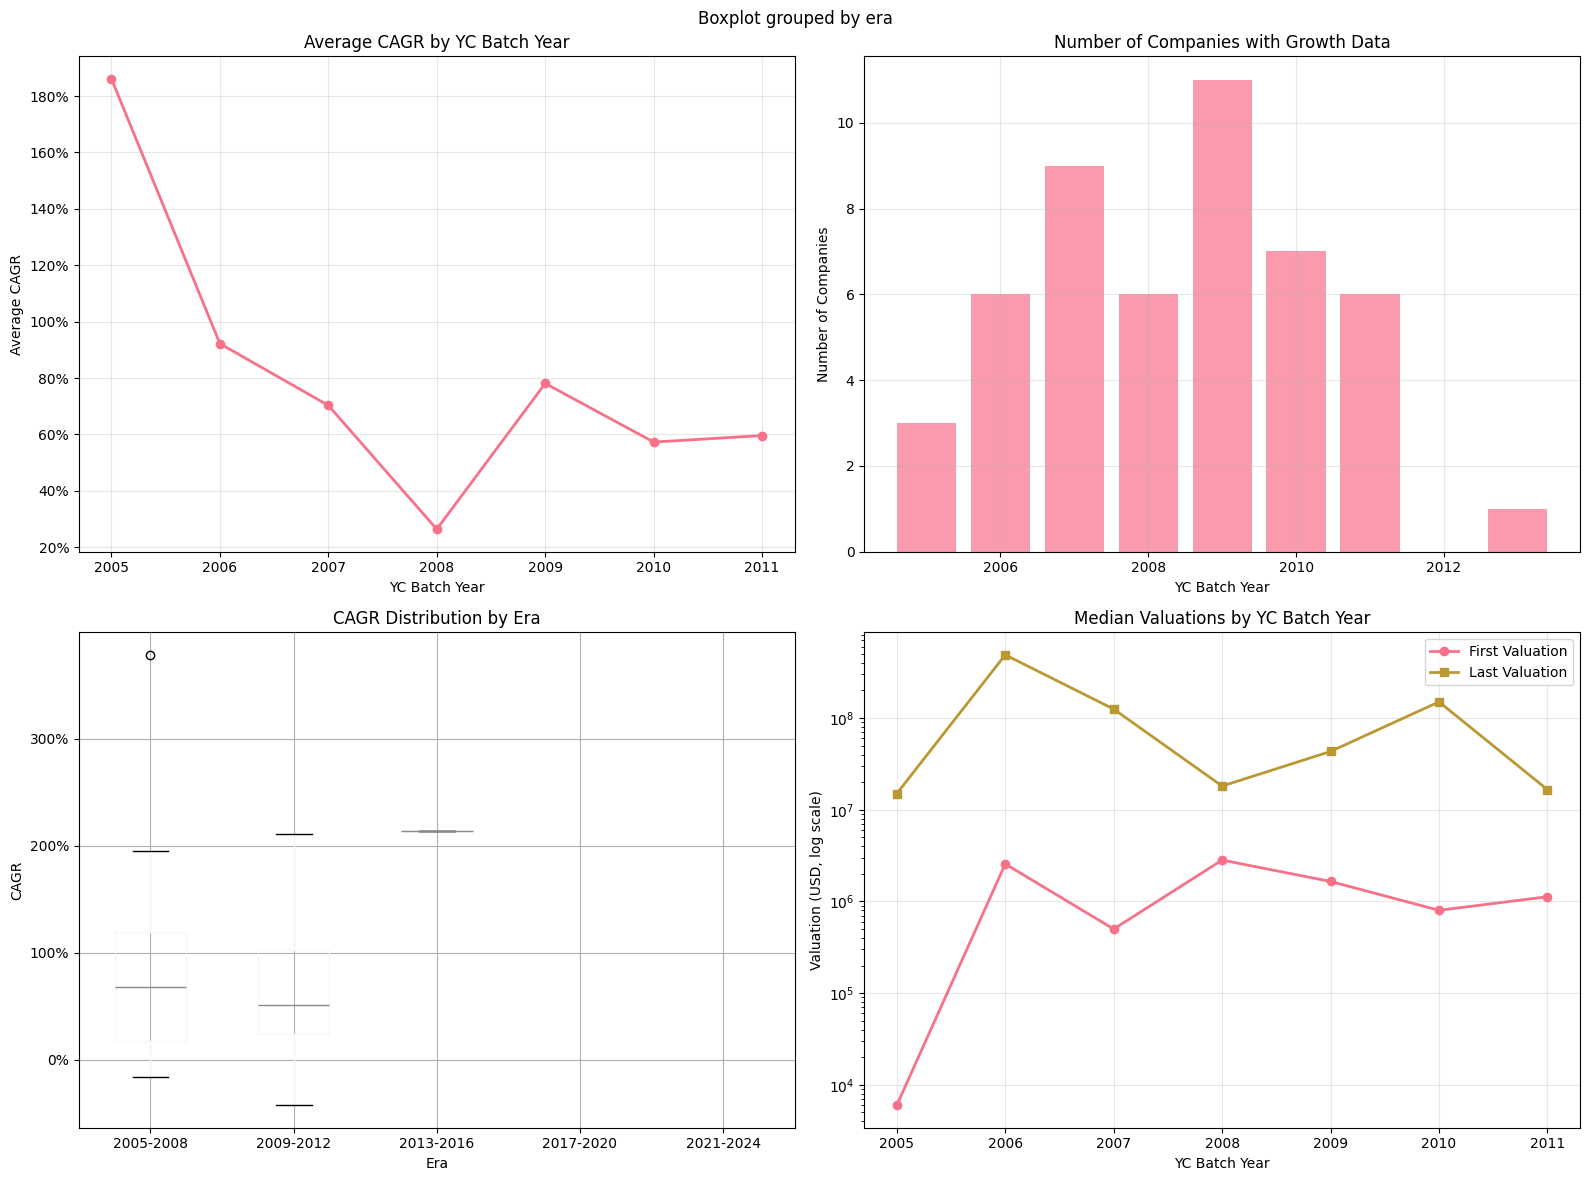

In [11]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Y Combinator Company Growth Analysis by Batch Year', fontsize=16, fontweight='bold')

# 1. Average CAGR by YC Year
ax1 = axes[0, 0]
yearly_stats_filtered = yearly_stats[yearly_stats['cagr_count'] >= 3]  # At least 3 companies
ax1.plot(yearly_stats_filtered['yc_year'], yearly_stats_filtered['cagr_mean'], marker='o', linewidth=2, markersize=6)
ax1.set_title('Average CAGR by YC Batch Year')
ax1.set_xlabel('YC Batch Year')
ax1.set_ylabel('Average CAGR')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# 2. Number of companies with growth data by year
ax2 = axes[0, 1]
ax2.bar(yearly_stats['yc_year'], yearly_stats['cagr_count'], alpha=0.7)
ax2.set_title('Number of Companies with Growth Data')
ax2.set_xlabel('YC Batch Year')
ax2.set_ylabel('Number of Companies')
ax2.grid(True, alpha=0.3)

# 3. CAGR distribution by era
ax3 = axes[1, 0]
# Group years into eras
filtered_growth['era'] = pd.cut(filtered_growth['yc_year'], 
                               bins=[2004, 2008, 2012, 2016, 2020, 2025], 
                               labels=['2005-2008', '2009-2012', '2013-2016', '2017-2020', '2021-2024'])

filtered_growth.boxplot(column='cagr', by='era', ax=ax3)
ax3.set_title('CAGR Distribution by Era')
ax3.set_xlabel('Era')
ax3.set_ylabel('CAGR')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# 4. Median first vs last valuation by year
ax4 = axes[1, 1]
ax4.semilogy(yearly_stats_filtered['yc_year'], yearly_stats_filtered['first_valuation_median'], 
             marker='o', label='First Valuation', linewidth=2)
ax4.semilogy(yearly_stats_filtered['yc_year'], yearly_stats_filtered['last_valuation_median'], 
             marker='s', label='Last Valuation', linewidth=2)
ax4.set_title('Median Valuations by YC Batch Year')
ax4.set_xlabel('YC Batch Year')
ax4.set_ylabel('Valuation (USD, log scale)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Detailed Analysis by Company Status

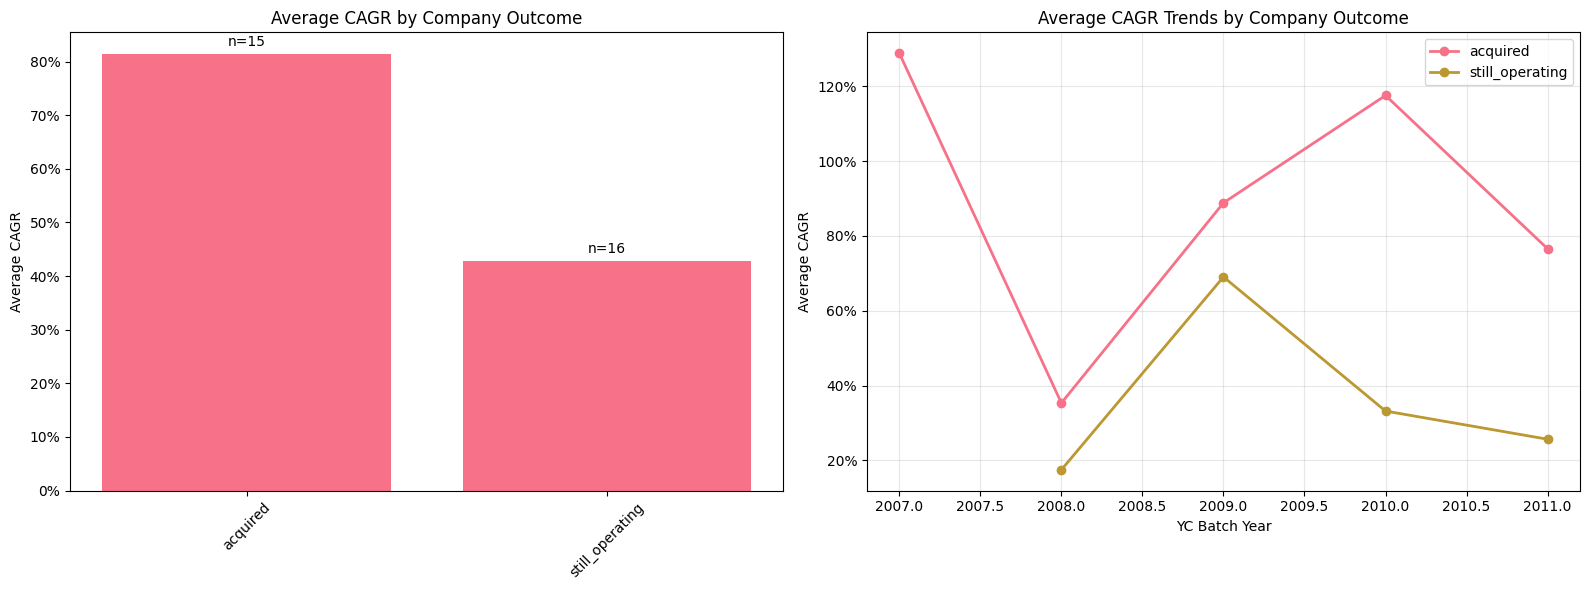

In [12]:
# Analysis by end reason
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CAGR by end reason
ax1 = axes[0]
end_reason_stats = filtered_growth.groupby('end_reason')['cagr'].agg(['count', 'mean', 'median']).reset_index()
end_reason_stats = end_reason_stats[end_reason_stats['count'] >= 5]  # At least 5 companies

bars = ax1.bar(end_reason_stats['end_reason'], end_reason_stats['mean'])
ax1.set_title('Average CAGR by Company Outcome')
ax1.set_ylabel('Average CAGR')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax1.tick_params(axis='x', rotation=45)

# Add count labels on bars
for bar, count in zip(bars, end_reason_stats['count']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'n={count}', ha='center', va='bottom')

# Growth over time by outcome
ax2 = axes[1]
for outcome in filtered_growth['end_reason'].unique():
    if pd.notna(outcome):
        outcome_data = filtered_growth[filtered_growth['end_reason'] == outcome]
        yearly_outcome = outcome_data.groupby('yc_year')['cagr'].mean()
        if len(yearly_outcome) > 2:  # Only plot if we have data for multiple years
            ax2.plot(yearly_outcome.index, yearly_outcome.values, marker='o', label=outcome, linewidth=2)

ax2.set_title('Average CAGR Trends by Company Outcome')
ax2.set_xlabel('YC Batch Year')
ax2.set_ylabel('Average CAGR')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

plt.tight_layout()
plt.show()

## 6. Top Performers Analysis

In [13]:
# Top performers by CAGR
print("🏆 Top 10 Companies by CAGR:")
top_cagr = filtered_growth.nlargest(10, 'cagr')[['company', 'yc_year', 'cagr', 'total_growth', 'years_tracked', 'end_reason']]
top_cagr['cagr_formatted'] = top_cagr['cagr'].apply(lambda x: f"{x:.1%}")
top_cagr['total_growth_formatted'] = top_cagr['total_growth'].apply(lambda x: f"{x:.1f}x")
display(top_cagr[['company', 'yc_year', 'cagr_formatted', 'total_growth_formatted', 'years_tracked', 'end_reason']])

print("\n🚀 Top 10 Companies by Total Growth:")
top_total = filtered_growth.nlargest(10, 'total_growth')[['company', 'yc_year', 'cagr', 'total_growth', 'years_tracked', 'end_reason']]
top_total['cagr_formatted'] = top_total['cagr'].apply(lambda x: f"{x:.1%}")
top_total['total_growth_formatted'] = top_total['total_growth'].apply(lambda x: f"{x:.1f}x")
display(top_total[['company', 'yc_year', 'cagr_formatted', 'total_growth_formatted', 'years_tracked', 'end_reason']])

🏆 Top 10 Companies by CAGR:


,company,yc_year,cagr_formatted,total_growth_formatted,years_tracked,end_reason
1,Loopt,2005,378.2%,2500.0x,5,None
62,DoorDash,2013,213.6%,906000.0x,12,None
44,FutureAdvisor,2010,210.7%,30.0x,3,acquired
34,Lockitron,2009,197.2%,232.0x,5,acquired
6,OMGPop,2006,194.7%,8.7x,2,None
55,Caviar,2011,162.8%,2277.8x,8,acquired
29,Airbnb,2009,158.0%,3850000.0x,16,still_operating
10,Xobni,2006,150.0%,244.2x,6,None
0,Clickfacts,2005,129.5%,335.3x,7,None
21,Weebly,2007,128.9%,753.8x,8,acquired



🚀 Top 10 Companies by Total Growth:


,company,yc_year,cagr_formatted,total_growth_formatted,years_tracked,end_reason
29,Airbnb,2009,158.0%,3850000.0x,16,still_operating
62,DoorDash,2013,213.6%,906000.0x,12,None
9,Wufoo,2006,73.8%,12000.0x,17,None
15,Disqus,2007,70.2%,8400.0x,17,None
8,Scribd,2006,82.6%,8333.3x,15,None
19,Songkick,2007,124.6%,7333.3x,11,None
13,Clickpass,2007,107.2%,6250.0x,12,None
38,Stripe,2009,69.3%,4575.0x,16,still_operating
43,Docker,2010,69.0%,2625.0x,15,still_operating
1,Loopt,2005,378.2%,2500.0x,5,None


## 7. Summary Statistics and Insights

In [14]:
# Summary statistics
print("📊 OVERALL GROWTH STATISTICS")
print("=" * 50)
print(f"Total companies analyzed: {len(filtered_growth)}")
print(f"YC years covered: {filtered_growth['yc_year'].min()} - {filtered_growth['yc_year'].max()}")
print(f"Average tracking period: {filtered_growth['years_tracked'].mean():.1f} years")
print()
print("CAGR Statistics:")
print(f"  Mean: {filtered_growth['cagr'].mean():.1%}")
print(f"  Median: {filtered_growth['cagr'].median():.1%}")
print(f"  75th percentile: {filtered_growth['cagr'].quantile(0.75):.1%}")
print(f"  90th percentile: {filtered_growth['cagr'].quantile(0.90):.1%}")
print()
print("Total Growth Statistics:")
print(f"  Mean: {filtered_growth['total_growth'].mean():.1f}x")
print(f"  Median: {filtered_growth['total_growth'].median():.1f}x")
print(f"  75th percentile: {filtered_growth['total_growth'].quantile(0.75):.1f}x")
print(f"  90th percentile: {filtered_growth['total_growth'].quantile(0.90):.1f}x")

# Era comparison
print("\n📈 GROWTH BY ERA")
print("=" * 50)
era_stats = filtered_growth.groupby('era').agg({
    'cagr': ['count', 'mean', 'median'],
    'total_growth': ['mean', 'median']
}).round(3)

for era in filtered_growth['era'].unique():
    if pd.notna(era):
        era_data = filtered_growth[filtered_growth['era'] == era]
        print(f"\n{era}:")
        print(f"  Companies: {len(era_data)}")
        print(f"  Avg CAGR: {era_data['cagr'].mean():.1%}")
        print(f"  Median CAGR: {era_data['cagr'].median():.1%}")
        print(f"  Avg Total Growth: {era_data['total_growth'].mean():.1f}x")

# Outcome comparison
print("\n🎯 GROWTH BY OUTCOME")
print("=" * 50)
for outcome in filtered_growth['end_reason'].value_counts().index[:5]:
    outcome_data = filtered_growth[filtered_growth['end_reason'] == outcome]
    print(f"\n{outcome}:")
    print(f"  Companies: {len(outcome_data)}")
    print(f"  Avg CAGR: {outcome_data['cagr'].mean():.1%}")
    print(f"  Median CAGR: {outcome_data['cagr'].median():.1%}")
    print(f"  Avg Total Growth: {outcome_data['total_growth'].mean():.1f}x")

📊 OVERALL GROWTH STATISTICS
Total companies analyzed: 49
YC years covered: 2005 - 2013
Average tracking period: 9.8 years

CAGR Statistics:
  Mean: 76.2%
  Median: 62.6%
  75th percentile: 117.3%
  90th percentile: 169.2%

Total Growth Statistics:
  Mean: 98293.8x
  Median: 62.5x
  75th percentile: 753.8x
  90th percentile: 7533.3x

📈 GROWTH BY ERA

2005-2008:
  Companies: 24
  Avg CAGR: 79.2%
  Median CAGR: 67.7%
  Avg Total Growth: 2029.3x

2009-2012:
  Companies: 24
  Avg CAGR: 67.4%
  Median CAGR: 50.9%
  Avg Total Growth: 160903.8x

2013-2016:
  Companies: 1
  Avg CAGR: 213.6%
  Median CAGR: 213.6%
  Avg Total Growth: 906000.0x

🎯 GROWTH BY OUTCOME

still_operating:
  Companies: 16
  Avg CAGR: 42.7%
  Median CAGR: 42.3%
  Avg Total Growth: 241203.4x

acquired:
  Companies: 15
  Avg CAGR: 81.4%
  Median CAGR: 67.7%
  Avg Total Growth: 258.2x


## 8. Key Insights and Conclusions

### Key Findings:

1. **Growth Rate Trends**: Analyze how the average CAGR of YC companies has changed over different batch years

2. **Era Comparison**: Compare growth patterns across different eras (early 2000s, 2010s, recent years)

3. **Outcome Impact**: Examine how different company outcomes (acquisition, IPO, still operating) correlate with growth rates

4. **Market Conditions**: Identify potential impacts of market conditions and technology cycles on startup growth

5. **Top Performers**: Highlight exceptional growth companies and their characteristics

### Methodology Notes:
- Growth rates calculated using CAGR (Compound Annual Growth Rate)
- Outliers filtered to remove likely data errors
- Only companies with at least 2 years of valuation data included
- Valuations parsed from various text formats to numeric values

### Data Limitations:
- Not all companies have complete valuation histories
- Some valuations may be estimates or unverified
- Private company valuations may not reflect true market value
- Survival bias: analysis only includes companies with available data